# CCMA to PhenPred preprocessing
This notebook inspects raw CCMA files in `PhenPred/data/CCMA/` and converts them to PhenPred-compatible layouts.

Planned outputs:
- `cas12.csv` -> `crisprcas9_ccma.csv` (samples x features, first column `ModelID`)
- `rnaseq.csv` -> `transcriptomics_ccma.csv` (features x samples, blank first header)
- `ccma_promoter.csv` -> `methylation_ccma.csv` (features x samples)
- `epic.csv` -> `methylation_ccma.csv` (features x samples, optional fallback because it is very memory-heavy)
- `snv.csv` -> `mutations_summary_ccma.csv` (long format: `model_id`, `gene_symbol`, `cancer_driver`)

Note: CCMA sample IDs are 64-character hashes (not `SIDM`/`ACH-*`). Without an external mapping file, these cannot be aligned to the standard PhenPred samplesheet IDs.


In [2]:
from pathlib import Path
import csv
import warnings

import numpy as np
import pandas as pd

PROJECT_ROOT = Path('/mnt/hackathon-team2-8bf1s/scai/PhenPred')
CCMA_DIR = PROJECT_ROOT / 'data' / 'CCMA'
OUT_DIR = PROJECT_ROOT / 'data' / 'clines' / 'ccma_processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PROMOTER_METH_PATH = Path('/mnt/hackathon-team2-8bf1s/CCMA/ccma_promoter.csv')
PROCESS_PROMOTER = True

# Optional fallback: transpose ~1.07M EPIC probes if promoter methylation is unavailable.
PROCESS_EPIC = False

# Optional pilot mode for epic transpose; leave None to process full file when PROCESS_EPIC=True.
EPIC_MAX_FEATURES = None

print(f'CCMA_DIR={CCMA_DIR}')
print(f'OUT_DIR={OUT_DIR}')
print(f'PROMOTER_METH_PATH={PROMOTER_METH_PATH}')


CCMA_DIR=/mnt/hackathon-team2-8bf1s/scai/PhenPred/data/CCMA
OUT_DIR=/mnt/hackathon-team2-8bf1s/scai/PhenPred/data/clines/ccma_processed
PROMOTER_METH_PATH=/mnt/hackathon-team2-8bf1s/CCMA/ccma_promoter.csv


In [ ]:
def quick_csv_schema(path, preview_cols=6):
    with open(path, newline='') as fh:
        reader = csv.reader(fh)
        header = next(reader)
        n_rows = sum(1 for _ in reader)
    return {    
        'file': path.name,
        'rows_without_header': n_rows,
        'n_cols': len(header),
        'first_col_name': header[0],
        'header_preview': header[:preview_cols],
    }

files = ['cas12.csv', 'rnaseq.csv', 'epic.csv', 'snv.csv']
schema = [quick_csv_schema(CCMA_DIR / f) for f in files]
if PROMOTER_METH_PATH.exists():
    schema.append(quick_csv_schema(PROMOTER_METH_PATH))
pd.DataFrame(schema)


,file,rows_without_header,n_cols,first_col_name,header_preview
0,cas12.csv,164,19842,ID,"[ID, CBSL, CH507-42P11.6, CNPY3-GNMT, ENSG0000..."
1,rnaseq.csv,385,63242,ID,"[ID, ENSG00000000003__TSPAN6, ENSG00000000005_..."
2,epic.csv,320,1074776,ID,"[ID, cg00000029, cg00000103, cg00000109, cg000..."
3,snv.csv,313,753,ID,"[ID, WARS2_snv, NEK1_snv, PRKDC_snv, KLHL6_snv..."
4,ccma_promoter.csv,353,12147,ID,"[ID, A1BG, A4GALT, AAAS, AACS, AADAT]"


In [ ]:
# Cross-file sample ID overlap check
id_sets = {}
for f in files:
    p = CCMA_DIR / f
    with open(p, newline='') as fh:
        r = csv.reader(fh)
        next(r)
        ids = [row[0] for row in r]
    id_sets[f] = set(ids)
    sidm = sum(1 for x in ids if x.startswith('SIDM'))
    ach = sum(1 for x in ids if x.startswith('ACH-'))
    print(f"{f}: n={len(ids)} unique={len(set(ids))} SIDM={sidm} ACH={ach} example={ids[0][:20]}...")

print("\nPairwise overlaps")
for i, a in enumerate(files):
    for b in files[i + 1 :]:
        print(f"{a} vs {b}: {len(id_sets[a] & id_sets[b])}")

shared_all = set.intersection(*[id_sets[f] for f in files])
print(f"\nIDs shared by all 4 files: {len(shared_all)}")


cas12.csv: n=164 unique=164 SIDM=0 ACH=0 example=272349fc0097407ed37e...
rnaseq.csv: n=385 unique=385 SIDM=0 ACH=0 example=8ecfbe46735df2391a19...


KeyboardInterrupt: 

In [ ]:
def normalize_feature_name(name, strip_snv_suffix=False):
    x = str(name).strip()

    # CCMA uses ENSGxxxx__SYMBOL in rnaseq/cas12.
    if '__' in x:
        x = x.split('__', 1)[1]

    if strip_snv_suffix and x.endswith('_snv'):
        x = x[: -len('_snv')]

    return x


def dedupe_columns_by_mean(df):
    # Collapse duplicate feature names after symbol normalization.
    return df.T.groupby(level=0).mean().T


def dedupe_index_by_mean(df):
    return df.groupby(level=0).mean()


In [ ]:
# 1) cas12 -> PhenPred-like crisprcas9 matrix (samples x features)
cas12_raw = pd.read_csv(CCMA_DIR / 'cas12.csv', low_memory=False)
cas12 = cas12_raw.rename(columns={cas12_raw.columns[0]: 'ModelID'}).set_index('ModelID')
cas12 = cas12.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')
cas12.columns = [normalize_feature_name(c) for c in cas12.columns]
cas12 = dedupe_columns_by_mean(cas12)

cas12_out = OUT_DIR / 'crisprcas9_ccma.csv'
cas12.to_csv(cas12_out, index=True, index_label='ModelID')

print('cas12_out:', cas12_out)
print('shape:', cas12.shape)
print('first 5 columns:', cas12.columns[:5].tolist())


cas12_out: /mnt/hackathon-team2-8bf1s/scai/PhenPred/data/clines/ccma_processed/crisprcas9_ccma.csv
shape: (164, 19841)
first 5 columns: ['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A3GALT2']


In [ ]:
cas12 = pd.read_csv(OUT_DIR / 'crisprcas9_ccma.csv', index_col=0)

In [10]:
cas12['MDM2']

ModelID
272349fc0097407ed37ea7afd8fae76188f6f98ccce6971e1ec5694329a680fa   -3.789734
119f658903506c570633463bca21cb8cf4a686015cded71861d89ad79a280fa3   -0.000946
9ebf79c6c14a29bda6e51b76ece4803579e19c771698009426965fc0bfdad896   -1.818239
f927abad5a8c3ab2dd9a4a51ee64d53dfe1da0d0154b22017c14f16712154ee4   -1.904317
e94806f24c3bec94dca88562479e3fc98215e1225ca3b980057b49da4cf504e1   -0.156389
                                                                      ...   
579bd6956a470c3c2a2dda5f4c2b8aa1bfa0d322110d6177a58f340363a298f5   -3.509198
5634a483ee8d344fd6c357e759c578fdc26d323995f73471d7d0c068fcecd9f3   -1.395863
d4f1c0f35ca8e055ce1effe563be67cccf1b8036941b380df2421115a67d8bd2    0.039317
f874d07567cbc4917ad4131e62c15205a4a333c50a82c0d128eb7b00263102e6   -1.412323
b91248fc1257cbfcc8207a9f64cc1486e206a269c0dc94ab741e93a066626d21   -0.195529
Name: MDM2, Length: 164, dtype: float64

In [15]:
# 2) rnaseq -> PhenPred-like transcriptomics matrix (features x samples)
rna_raw = pd.read_csv(CCMA_DIR / 'rnaseq.csv', low_memory=False)
rna = rna_raw.rename(columns={rna_raw.columns[0]: 'ID'}).set_index('ID')
rna = rna.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')

# Transpose to match PhenPred transcriptomics file layout.
rna_t = rna.T
rna_t.index = [normalize_feature_name(x) for x in rna_t.index]
rna_t = dedupe_index_by_mean(rna_t)

rna_out = OUT_DIR / 'transcriptomics_ccma.csv'
rna_t.to_csv(rna_out, index=True, index_label='')

print('rna_out:', rna_out)
print('shape:', rna_t.shape)
print('first 5 features:', rna_t.index[:5].tolist())


rna_out: /mnt/hackathon-team2-8bf1s/scai/PhenPred/data/clines/ccma_processed/transcriptomics_ccma.csv
shape: (61617, 385)
first 5 features: ['5S_rRNA', '5_8S_rRNA', '7SK', 'A1BG', 'A1BG-AS1']


In [16]:
# 3) snv -> mutation outputs
snv_raw = pd.read_csv(CCMA_DIR / 'snv.csv', low_memory=False)
snv = snv_raw.rename(columns={snv_raw.columns[0]: 'ID'}).set_index('ID')
snv = snv.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce').fillna(0)
snv.columns = [normalize_feature_name(c, strip_snv_suffix=True) for c in snv.columns]

# Keep max across duplicate symbols (binary matrix semantics).
snv = snv.T.groupby(level=0).max().T
snv_bin = (snv > 0).astype(np.int8)

# 3a) Binary matrix (features x samples)
snv_matrix_out = OUT_DIR / 'mutations_binary_ccma.csv'
snv_bin.T.to_csv(snv_matrix_out, index=True, index_label='gene_symbol')

# 3b) Long format compatible with PhenPred mutation label import pattern
mut_long = snv_bin.stack().rename('value').reset_index()
mut_long.columns = ['model_id', 'gene_symbol', 'value']
mut_long = mut_long[mut_long['value'] > 0].drop(columns=['value'])
mut_long['cancer_driver'] = True
mut_long['source'] = 'CCMA_snv'

mut_long_out = OUT_DIR / 'mutations_summary_ccma.csv'
mut_long.to_csv(mut_long_out, index=False)

print('snv_matrix_out:', snv_matrix_out, 'shape=', snv_bin.T.shape)
print('mut_long_out:', mut_long_out, 'rows=', len(mut_long))
print(mut_long.head())


snv_matrix_out: /mnt/hackathon-team2-8bf1s/scai/PhenPred/data/clines/ccma_processed/mutations_binary_ccma.csv shape= (752, 313)
mut_long_out: /mnt/hackathon-team2-8bf1s/scai/PhenPred/data/clines/ccma_processed/mutations_summary_ccma.csv rows= 2081
                                               model_id gene_symbol  \
437   29596e5c9b6bbb31531f392a4f7e7c43108d27ca5e6bb8...        NEK1   
519   29596e5c9b6bbb31531f392a4f7e7c43108d27ca5e6bb8...       PRKDC   
731   29596e5c9b6bbb31531f392a4f7e7c43108d27ca5e6bb8...       WARS2   
1105  6724a2a2d31860943f7685f2a8a94ccd1e6177624a6f5a...       KLHL6   
1548  9c2d36e54fc6ef63145973506e99e84162a3f48d863442...  AP002748_5   

      cancer_driver    source  
437            True  CCMA_snv  
519            True  CCMA_snv  
731            True  CCMA_snv  
1105           True  CCMA_snv  
1548           True  CCMA_snv  


In [17]:
# 4) methylation -> PhenPred-like methylation matrix (features x samples)
# Prefer promoter methylation (gene-level); optionally fall back to EPIC probes.

methyl_out = OUT_DIR / 'methylation_ccma.csv'
methyl_written = False

if PROCESS_PROMOTER and PROMOTER_METH_PATH.exists():
    meth_raw = pd.read_csv(PROMOTER_METH_PATH, low_memory=False)
    meth = meth_raw.rename(columns={meth_raw.columns[0]: 'ID'}).set_index('ID')
    meth = meth.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')

    meth_t = meth.T
    meth_t.index = [normalize_feature_name(x) for x in meth_t.index]
    meth_t = dedupe_index_by_mean(meth_t)
    meth_t.to_csv(methyl_out, index=True, index_label='')
    methyl_written = True

    print('methylation source:', PROMOTER_METH_PATH)
    print('methyl_out:', methyl_out)
    print('shape:', meth_t.shape)
elif PROCESS_EPIC:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        epic_raw = pd.read_csv(CCMA_DIR / 'epic.csv', low_memory=False)

    epic = epic_raw.rename(columns={epic_raw.columns[0]: 'ID'}).set_index('ID')
    if EPIC_MAX_FEATURES is not None:
        epic = epic.iloc[:, :EPIC_MAX_FEATURES]

    epic = epic.replace('NA', np.nan).apply(pd.to_numeric, errors='coerce')
    epic_t = epic.T
    epic_t.to_csv(methyl_out, index=True, index_label='')
    methyl_written = True

    print('methylation source:', CCMA_DIR / 'epic.csv')
    print('methyl_out:', methyl_out)
    print('shape:', epic_t.shape)
else:
    print('Skipped methylation. Set PROCESS_PROMOTER=True or PROCESS_EPIC=True to generate methylation_ccma.csv')


methylation source: /mnt/hackathon-team2-8bf1s/CCMA/ccma_promoter.csv
methyl_out: /mnt/hackathon-team2-8bf1s/scai/PhenPred/data/clines/ccma_processed/methylation_ccma.csv
shape: (12146, 353)


In [11]:
# 5) Minimal compatibility check + dataset dictionary snippet

def header_preview(path, n=6):
    with open(path, newline='') as fh:
        r = csv.reader(fh)
        h = next(r)
    return h[:n]

print('crispr header preview:', header_preview(cas12_out))
print('rna header preview:', header_preview(rna_out))
print('snv long columns:', pd.read_csv(mut_long_out, nrows=0).columns.tolist())
if 'methyl_written' in globals() and methyl_written:
    print('methylation header preview:', header_preview(methyl_out))

ccma_datasets_for_hypers = {
    'crisprcas9': str(cas12_out),
    'transcriptomics': str(rna_out),
}
if 'methyl_written' in globals() and methyl_written:
    ccma_datasets_for_hypers['methylation'] = str(methyl_out)

print("\nUse this in a Hyperparameters config (paths are absolute):")
print(ccma_datasets_for_hypers)

print("\nReminder: sample IDs are hashed. Provide a mapping file if you need SIDM/ACH alignment.")


crispr header preview: ['ModelID', 'A1BG', 'A1CF', 'A2M', 'A2ML1', 'A3GALT2']


NameError: name 'rna_out' is not defined

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Variance of CRISPR genes ────────────────────────────────────────────────
cas12 = pd.read_csv(OUT_DIR / 'crisprcas9_ccma.csv', index_col=0)

gene_var = cas12.var(axis=0).dropna().sort_values(ascending=False)
gene_var.name = 'variance'

print(f"Total genes: {len(gene_var)}")
print(f"\nTop 20 by variance:\n{gene_var.head(20).to_string()}")


Total genes: 19841

Top 20 by variance:
CDK6        1.265260
RAN         1.087676
MED31       1.057427
MAT2A       1.024202
KIF18A      1.021946
SCART1      1.012091
XPO1        1.004168
ELP2        0.966121
CENPP       0.963337
GMPS        0.960835
COP1        0.951092
MED12       0.945440
PAFAH1B1    0.944417
YARS2       0.941539
RPL14       0.881661
RRM1        0.881558
SMC5        0.852420
FXN         0.849507
COPS5       0.838807
ANKLE2      0.838081


NameError: name 'gene_var' is not defined

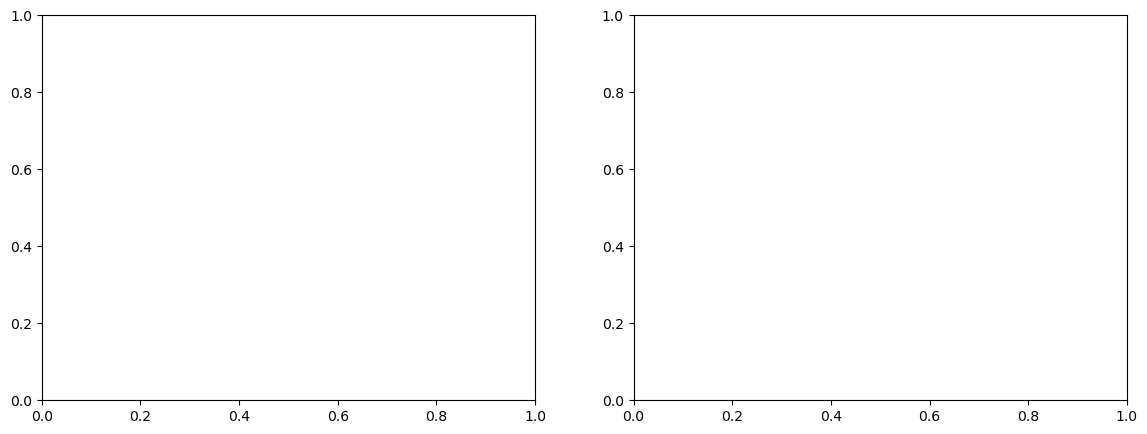

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram of per-gene variance ────────────────────────────────────
ax = axes[0]
ax.hist(gene_var.values, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
ax.set_xlabel('Gene variance (across cell lines)', fontsize=12)
ax.set_ylabel('Number of genes', fontsize=12)
ax.set_title('Distribution of CRISPR gene variance', fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
pcts = [
    (0.90, 'tomato',     '90th pct'),
    (0.95, 'darkorange', '95th pct'),
    (0.99, 'purple',     '99th pct'),
]
ylim_top = ax.get_ylim()[1]
for q, color, label in pcts:
    thresh = gene_var.quantile(q)
    n_above = int((gene_var >= thresh).sum())
    ax.axvline(thresh, color=color, lw=1.5, ls='--', label=f'{label} (n={n_above:,})')
    ax.text(thresh, ylim_top * 0.97, f' n={n_above:,}', color=color,
            fontsize=12, va='top', ha='left', rotation=90)
ax.legend(fontsize=12)

# ── Right: top-N ranked bar chart ───────────────────────────────────────────
TOP_N_PLOT = 40
ax2 = axes[1]
top_plot = gene_var.head(TOP_N_PLOT)
bars = ax2.barh(top_plot.index[::-1], top_plot.values[::-1], color='steelblue', alpha=0.85)
ax2.set_xlabel('Variance', fontsize=12)
ax2.set_title(f'Top {TOP_N_PLOT} most variable CRISPR genes', fontsize=13)
ax2.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'vae' / 'crispr_gene_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")


In [21]:
# ── Write top-N genes to shap_target_genes.txt ──────────────────────────────
# Adjust TOP_N_GENES to change how many genes are written.
TOP_N_GENES = 1000
SHAP_GENES_PATH = PROJECT_ROOT / 'reports' / 'vae' / 'files' / 'shap_target_genes.txt'

top_genes = gene_var.head(TOP_N_GENES).index.tolist()



In [22]:
"PIK3CA" in top_genes

True

In [23]:
with open(SHAP_GENES_PATH, 'w') as fh:
    fh.write('\n'.join(top_genes) + '\n')

print(f"Wrote {len(top_genes)} genes to {SHAP_GENES_PATH}")
print("Genes:", top_genes)


Wrote 1000 genes to /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/files/shap_target_genes.txt
Genes: ['CDK6', 'RAN', 'MED31', 'MAT2A', 'KIF18A', 'SCART1', 'XPO1', 'ELP2', 'CENPP', 'GMPS', 'COP1', 'MED12', 'PAFAH1B1', 'YARS2', 'RPL14', 'RRM1', 'SMC5', 'FXN', 'COPS5', 'ANKLE2', 'DHX36', 'SMC4', 'RUVBL1', 'RMI1', 'RPS29', 'RPS4X', 'WEE1', 'HSPA8', 'PPP1R15B', 'RPA1', 'MBTPS2', 'MDM2', 'PSMG1', 'DDX59', 'PLK4', 'CSNK1A1', 'RPL34', 'MYC', 'METAP1', 'ABCE1', 'COASY', 'SQLE', 'DCAF13', 'NCAPG', 'SHOC2', 'RBM39', 'CDK7', 'DHX15', 'BARD1', 'SKA2', 'ZBTB8OS', 'SMC3', 'EIF3M', 'IARS1', 'PRPF40A', 'EFTUD2', 'HIST1H3C', 'RPL32', 'RABGGTB', 'NCL', 'BCAS2', 'TRIM37', 'PFDN6', 'SF3A1', 'ATP6V1B2', 'RPS23', 'MDM4', 'RTTN', 'ACTL6A', 'FANCM', 'RPS8', 'POLR2B', 'EIF3I', 'SNRPG', 'CCND1', 'NGDN', 'CKAP5', 'ACTR10', 'SCFD1', 'PIK3CA', 'CPSF3', 'HAUS2', 'PRPF39', 'TRAPPC8', 'OIP5', 'YEATS4', 'GTF3A', 'CIAO1', 'XRN2', 'NAA15', 'DDX46', 'HNRNPK', 'H2BC21', 'NUTF2', 'RPLP0', 'THOC2', 'TWNK', 'KIF23', 'P

Total unique samples (union across all omics): 432
  Transcriptomics: N=385 measured, N=47 missing
  CRISPR-Cas12: N=164 measured, N=268 missing
  Methylation: N=353 measured, N=79 missing
  Mutations (SNV): N=313 measured, N=119 missing


/tmp/ipykernel_1240297/179577319.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


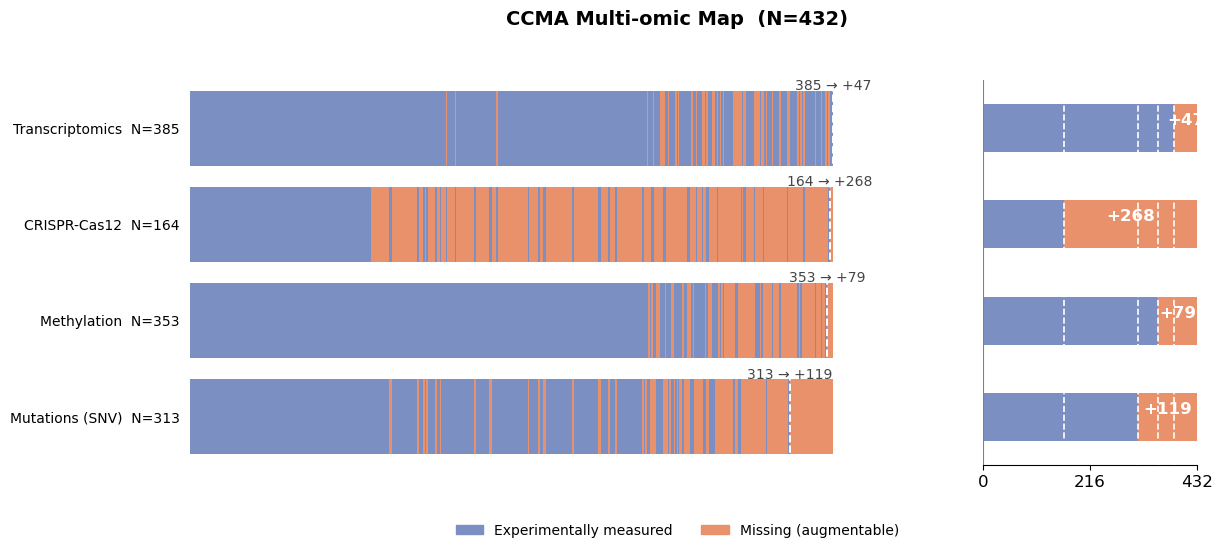

Figure saved to /mnt/hackathon-team2-8bf1s/scai/PhenPred/reports/vae/ccma_multiomic_map.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── Collect sample ID sets per omic ─────────────────────────────────────────
omic_files = {
    'Transcriptomics': (OUT_DIR / 'transcriptomics_ccma.csv',  'feat_x_samp'),
    'CRISPR-Cas12':    (OUT_DIR / 'crisprcas9_ccma.csv',       'samp_x_feat'),
    'Methylation':     (OUT_DIR / 'methylation_ccma.csv',      'feat_x_samp'),
    'Mutations (SNV)': (OUT_DIR / 'mutations_binary_ccma.csv', 'feat_x_samp'),
}

omic_sample_ids = {}
for omic, (path, layout) in omic_files.items():
    if not path.exists():
        print(f"Skipping {omic}: file not found at {path}")
        continue
    if layout == 'feat_x_samp':
        df_head = pd.read_csv(path, index_col=0, nrows=0)
        omic_sample_ids[omic] = set(df_head.columns)
    else:  # samp_x_feat
        df_idx = pd.read_csv(path, index_col=0, usecols=[0])
        omic_sample_ids[omic] = set(df_idx.index)

all_samples = sorted(set.union(*omic_sample_ids.values()))
N_total = len(all_samples)
sample_idx = {s: i for i, s in enumerate(all_samples)}

print(f"Total unique samples (union across all omics): {N_total}")
for omic, ids in omic_sample_ids.items():
    print(f"  {omic}: N={len(ids)} measured, N={N_total - len(ids)} missing")

# ── Build binary presence matrix (omics x samples) ──────────────────────────
omic_names = list(omic_sample_ids.keys())
presence = np.zeros((len(omic_names), N_total), dtype=np.int8)
for i, omic in enumerate(omic_names):
    for sid in omic_sample_ids[omic]:
        presence[i, sample_idx[sid]] = 1

# Sort samples: most-complete first (desc total measured omics), then alphabetically
completeness = presence.sum(axis=0)
sort_order = np.argsort(-completeness, kind='stable')
presence_sorted = presence[:, sort_order]

# ── Omic labels with counts ──────────────────────────────────────────────────
n_measured = presence.sum(axis=1)
n_augment  = N_total - n_measured
omic_labels = [f"{o}  N={n:,}" for o, n in zip(omic_names, n_measured)]

# ── Colours ──────────────────────────────────────────────────────────────────
CLR_MEASURED = '#7B8FC2'   # muted blue (experimentally measured)
CLR_AUGMENT  = '#E8916A'   # muted orange (missing → augmentable)

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5))
fig.patch.set_facecolor('white')

# Use gridspec: left panel wider, right panel narrower
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.35)
ax_rug  = fig.add_subplot(gs[0])
ax_bar  = fig.add_subplot(gs[1])

n_omics = len(omic_names)

# ── Left panel: per-sample rug / heatmap ─────────────────────────────────────
row_h   = 0.7   # height of each omic row
gap     = 0.2   # gap between rows
y_centers = [(n_omics - 1 - i) * (row_h + gap) for i in range(n_omics)]

for i in range(n_omics):
    row = presence_sorted[i]
    y0  = y_centers[i] - row_h / 2

    # Draw measured (blue) and missing (orange) rectangles per sample
    # For efficiency, draw one rectangle per contiguous run
    col_width = 1.0 / N_total
    for j, val in enumerate(row):
        color = CLR_MEASURED if val else CLR_AUGMENT
        ax_rug.add_patch(plt.Rectangle(
            (j / N_total, y0), col_width, row_h,
            color=color, linewidth=0
        ))

ax_rug.set_xlim(0, 1)
ax_rug.set_ylim(-row_h / 2 - gap / 2, y_centers[0] + row_h / 2 + gap / 2)
ax_rug.set_yticks(y_centers)
ax_rug.set_yticklabels(omic_labels, fontsize=10)
ax_rug.set_xticks([])
ax_rug.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax_rug.tick_params(left=False)

# ── Find per-omic boundary positions in the sorted sample space ──────────────
# boundary_x[i] = fraction along x-axis where the last measured sample for omic i falls
boundary_x = []
for i in range(n_omics):
    measured_positions = np.where(presence_sorted[i] == 1)[0]
    if len(measured_positions):
        last_measured = measured_positions.max()
        boundary_x.append((last_measured + 1) / N_total)
    else:
        boundary_x.append(0.0)

# ── Annotate rug: dashed vertical line + label at each omic's coverage boundary
for i in range(n_omics):
    bx = boundary_x[i]
    y0 = y_centers[i] - row_h / 2
    y1 = y_centers[i] + row_h / 2
    # Vertical dashed line spanning the row height
    ax_rug.plot([bx, bx], [y0 - gap * 0.4, y1 + gap * 0.4],
                color='white', lw=1.4, ls='--', zorder=5)
    # Count label above the line
    n_m = int(n_measured[i])
    n_a = int(n_augment[i])
    ax_rug.text(bx, y1 + gap * 0.55,
                f'{n_m:,} → +{n_a:,}',
                ha='center', va='top', fontsize=10,
                color='#444444', zorder=6)

# ── Right panel: stacked horizontal bar chart ─────────────────────────────────
bar_h = 0.45
for i in range(n_omics):
    y = y_centers[i]
    ax_bar.barh(y, n_measured[i], height=bar_h, color=CLR_MEASURED, left=0)
    ax_bar.barh(y, n_augment[i],  height=bar_h, color=CLR_AUGMENT,  left=n_measured[i])

    # Vertical line at the junction between measured and augmentable
    ax_bar.axvline(n_measured[i], ymin=0, ymax=1,
                   color='white', lw=1.2, ls='--', zorder=5)

    # Annotate +N_augment gain to the right of the orange bar
    ax_bar.text(n_measured[i] + n_augment[i] / 2, y,
                f'+{int(n_augment[i]):,}',
                ha='center', va='bottom', fontsize=12,
                color='white', fontweight='bold', zorder=6)

ax_bar.set_xlim(0, N_total)
ax_bar.set_ylim(ax_rug.get_ylim())
ax_bar.set_yticks([])
ax_bar.axvline(0, color='grey', lw=0.8)
ax_bar.set_xticks([0, N_total // 2, N_total])
ax_bar.set_xticklabels(['0', str(N_total // 2), str(N_total)], fontsize=12)
ax_bar.spines[['top', 'right', 'left']].set_visible(False)
ax_bar.tick_params(bottom=True)

# ── Shared title and legend ───────────────────────────────────────────────────
fig.suptitle(
    f"CCMA Multi-omic Map  (N={N_total:,})",
    fontsize=14, fontweight='bold', y=1.02
)

legend_patches = [
    mpatches.Patch(color=CLR_MEASURED, label='Experimentally measured'),
    mpatches.Patch(color=CLR_AUGMENT,  label='Missing (augmentable)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5, -0.06), fontsize=10, frameon=False)

plt.tight_layout()
out_path = PROJECT_ROOT / 'reports' / 'vae' / 'ccma_multiomic_map.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved to {out_path}")
